In [1]:
import matplotlib.pyplot as plt

import cv2

# New section

In [ ]:
def extract_plate(img):  # the function detects and performs blurring on the number plate.
    plate_img = img.copy()

    # Loads the data required for detecting the license plates from cascade classifier.
    plate_cascade = cv2.CascadeClassifier('./indian_license_plate.xml')

    # detects numberplates and returns the coordinates and dimensions of detected license plate's contours.
    plate_rect = plate_cascade.detectMultiScale(plate_img, scaleFactor=1.6, minNeighbors=7)

    for (x, y, w, h) in plate_rect:
        a, b = (int(0.02 * img.shape[0]), int(0.025 * img.shape[1]))  # parameter tuning
        plate = plate_img[y + a:y + h - a, x + b:x + w - b, :]
        # finally representing the detected contours by drawing rectangles around the edges.
        cv2.rectangle(plate_img, (x, y), (x + w, y + h), (51, 51, 255), 3)

    return plate_img, plate  # returning the processed image.


Found 864 images belonging to 36 classes.
Found 216 images belonging to 36 classes.
Epoch 1/10
864/864 [==============================] - 156s 180ms/step - loss: 3.4867 - accuracy: 0.0648 - val_loss: 3.0665 - val_accuracy: 0.1898
Epoch 2/10
864/864 [==============================] - 176s 203ms/step - loss: 2.5241 - accuracy: 0.2859 - val_loss: 1.9888 - val_accuracy: 0.5000
Epoch 3/10
864/864 [==============================] - 157s 181ms/step - loss: 1.7143 - accuracy: 0.5116 - val_loss: 1.2514 - val_accuracy: 0.7130
Epoch 4/10
864/864 [==============================] - 152s 176ms/step - loss: 1.3028 - accuracy: 0.6030 - val_loss: 1.0279 - val_accuracy: 0.7037
Epoch 5/10
864/864 [==============================] - 153s 177ms/step - loss: 1.0717 - accuracy: 0.6771 - val_loss: 0.8704 - val_accuracy: 0.8148
Epoch 6/10
864/864 [==============================] - 153s 178ms/step - loss: 0.9064 - accuracy: 0.7188 - val_loss: 0.6591 - val_accuracy: 0.8148
Epoch 7/10
864/864 [====================

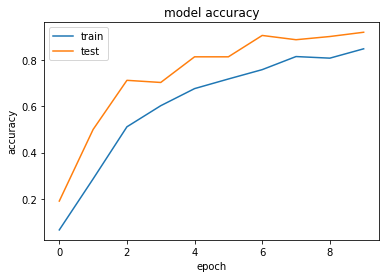

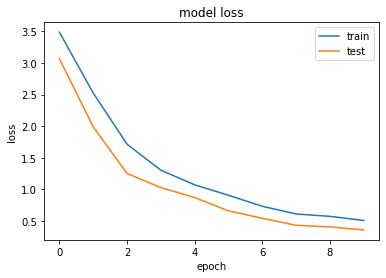

In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255, width_shift_range=0.1, height_shift_range=0.1)
train_generator = train_datagen.flow_from_directory(
        '/content/drive/MyDrive/data/train',  # this is the target directory
        target_size=(28,28),  # all images will be resized to 28x28
        batch_size=1,
        class_mode='categorical')

validation_generator = train_datagen.flow_from_directory(
        '/content/drive/MyDrive/data/val',  # this is the target directory
        target_size=(28,28), batch_size=1,
        class_mode='categorical')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Dropout, Conv2D
from tensorflow.keras import optimizers
model = Sequential()
model.add(Conv2D(32, (24,24), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(32, (20,20), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(32, (20,20), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(36, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer=optimizers.Adam(lr=0.00001), metrics=['accuracy'])
import datetime
log_dir="logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
batch_size = 1
callbacks = [tensorboard_callback,tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)]
history = model.fit(
      train_generator,
      steps_per_epoch = train_generator.samples // batch_size,
      validation_data = validation_generator,
      validation_steps = validation_generator.samples // batch_size,
      epochs = 10, callbacks=callbacks)

print(history.history.keys())

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()


# Save Model and Weights
model.save('model.h5')


